# Average damping vs low damping — relative reduction per DOF

Reads `Simulation_output_redo.csv`. Uses the corrected MPM `|MPM - Mean|`.

One figure for Section 4.3.2: the relative reduction of the **average** damping
case with respect to the **low** damping case, for heave, pitch and roll
(three subplots side by side). One line per Hs.

Mild sea states (Hs = 1, 2, 4 m) are drawn solid; the extreme sea states
(Hs = 6, 8 m) are drawn dashed, as the model assumptions are questionable
there. Directions are averaged (roll excludes 0 and 180).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 14

plt.rcParams.update({
    'axes.titlesize': TITLE_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'xtick.labelsize': TICK_SIZE,
    'ytick.labelsize': TICK_SIZE,
    'legend.fontsize': TICK_SIZE,
    'figure.titlesize': TITLE_SIZE,
})

In [2]:
df = pd.read_csv('Simulation_output_redo.csv')

for col in ['Damp_Heave', 'Damp_Roll', 'Damp_Pitch']:
    df[col] = df[col].replace({'DOFbest': 'average'})

for suffix in ['Z', 'pitch', 'roll']:
    df[f'MPM {suffix} corr'] = (df[f'MPM {suffix}'] - df[f'Mean {suffix}']).abs()

DOFS = [
    {'key': 'Z',     'name': 'Heave', 'drop_dirs': []},
    {'key': 'pitch', 'name': 'Pitch', 'drop_dirs': [0,90,135, 45    ]},
    {'key': 'roll',  'name': 'Roll',  'drop_dirs': [0,90, 135, 180]},
]

def damping_col(dof_key):
    return {'Z': 'Damp_Heave', 'pitch': 'Damp_Pitch', 'roll': 'Damp_Roll'}[dof_key]

def filter_dirs(sub, dof):
    if dof['drop_dirs']:
        sub = sub[~sub['Direction'].isin(dof['drop_dirs'])]
    return sub

# sea-state classification for line style
HS_ALL = sorted(df['Hs'].unique())
MILD = [1, 2, 4]                  # solid; the rest (6, 8) dashed
# HS_COLORS = {hs: c for hs, c in zip(HS_ALL, plt.cm.viridis(np.linspace(0, 0.85, len(HS_ALL))))}

def hs_style(hs):
    return '-' if hs in MILD else '--'

# count of rows per classification (for verification against your own tally)
n_mild = (df['Hs'].isin(MILD)).sum()
n_extreme = (~df['Hs'].isin(MILD)).sum()
print('Hs:', HS_ALL)
print('mild (solid):', MILD, '-> rows:', n_mild)
print('extreme (dashed):', [h for h in HS_ALL if h not in MILD], '-> rows:', n_extreme)

Hs: [np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8)]
mild (solid): [1, 2, 4] -> rows: 680
extreme (dashed): [np.int64(6), np.int64(8)] -> rows: 200


## Figure — average vs low, relative reduction, three DOFs

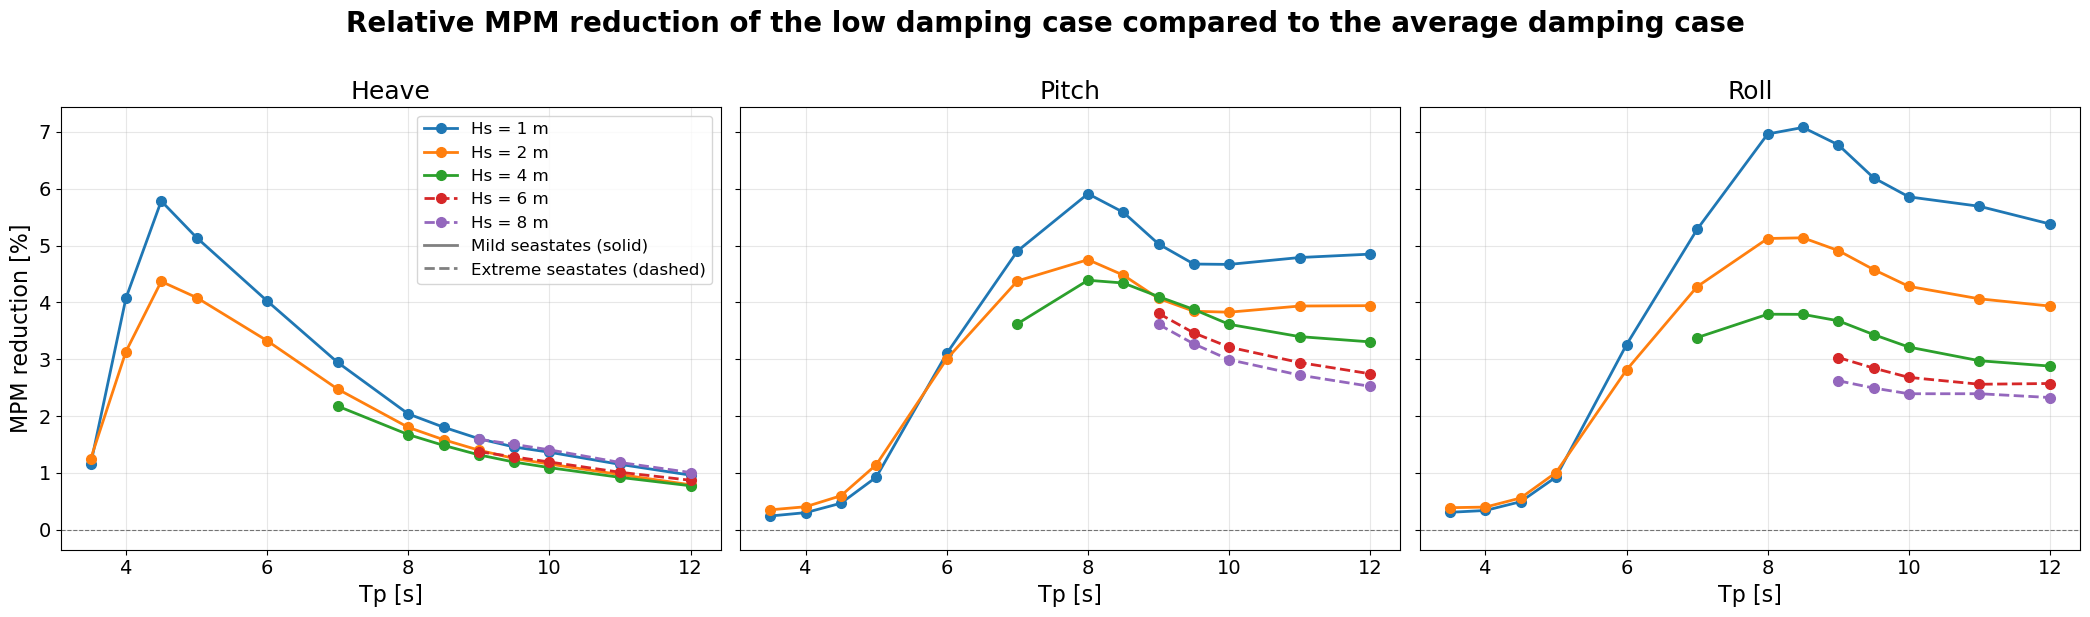

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6), squeeze=False, sharey=True)

for c, dof in enumerate(DOFS):
    ax = axes[0, c]
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    for hs in HS_ALL:
        sub_hs = sub_dof[sub_dof['Hs'] == hs]
        base = sub_hs[sub_hs[dcol] == 'average'].groupby('Tp')[mpm_c].mean().sort_index()
        avg = sub_hs[sub_hs[dcol] == 'low'].groupby('Tp')[mpm_c].mean().sort_index()
        common = base.index.intersection(avg.index)
        if len(common) == 0:
            continue
        pct = (avg.loc[common] - base.loc[common]) / base.loc[common] * 100
        ax.plot(common, pct, hs_style(hs), marker='o',
                linewidth=2, markersize=7, label=f'Hs = {hs} m')

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)
    ax.set_title(dof['name'], fontsize=TITLE_SIZE)
    ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)
    if c == 0:
        ax.set_ylabel('MPM reduction [%]', fontsize=LABEL_SIZE)

# legend: Hs colours + a line-style key for mild/extreme
handles, labels = axes[0, 0].get_legend_handles_labels()
style_handles = [
    Line2D([0], [0], color='grey', ls='-',  lw=2, label='Mild seastates (solid)'),
    Line2D([0], [0], color='grey', ls='--', lw=2, label='Extreme seastates (dashed)'),
]
axes[0, 0].legend(handles + style_handles, labels + ['Mild seastates (solid)', 'Extreme seastates (dashed)'],
                  fontsize=TICK_SIZE - 2, ncol=1, loc='best')

fig.suptitle('Relative MPM reduction of the low damping case compared to the average damping case',
             fontsize=TITLE_SIZE + 2, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('fig_avg_vs_low_perDOF.png', dpi=200, bbox_inches='tight')
plt.show()

## Appendix — all damping cases vs low, relative reduction

3x3 grid: rows = DOF (heave, pitch, roll), columns = damping case
(linhigh, quadhigh, average), each expressed as a relative reduction of the
MPM with respect to the low damping case. One line per Hs; mild solid,
extreme dashed. Directions are averaged (roll excludes 0 and 180).

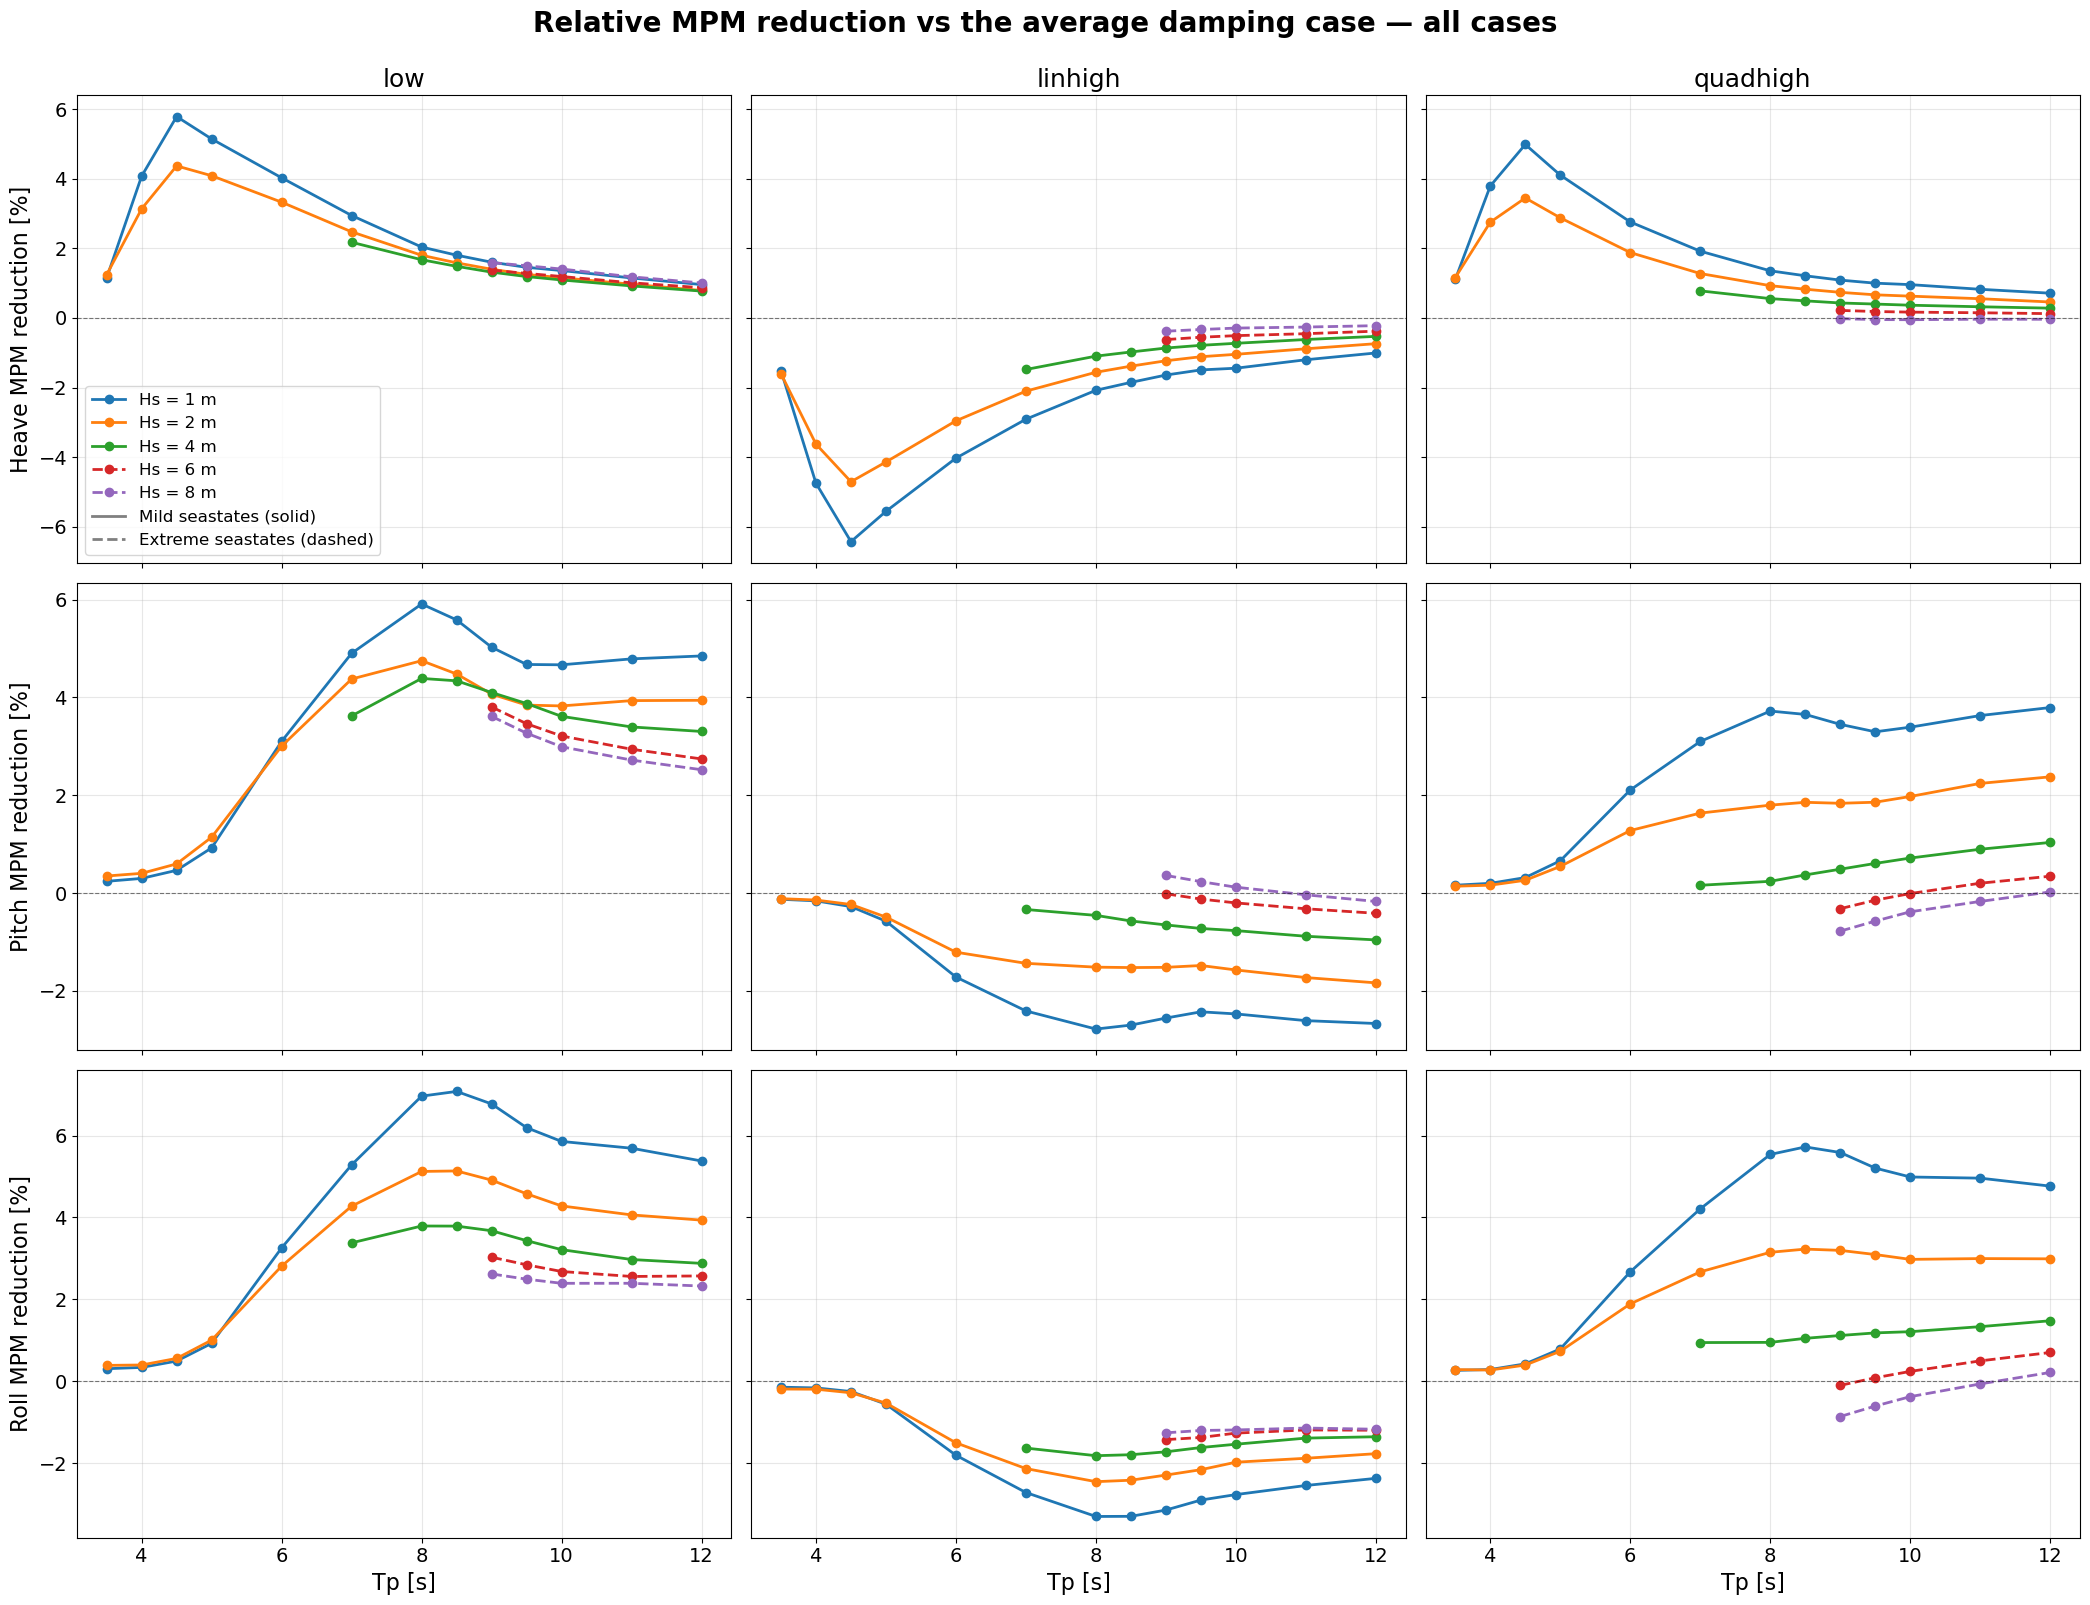

In [4]:
from matplotlib.lines import Line2D

CASES = ['low','linhigh', 'quadhigh' ]
HS_COLORS = {hs: c for hs, c in zip(HS_ALL, plt.cm.viridis(np.linspace(0, 0.85, len(HS_ALL))))}

fig, axes = plt.subplots(3, 3, figsize=(21, 16), squeeze=False, sharex=True, sharey='row')

for r, dof in enumerate(DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'
    for cc, case in enumerate(CASES):
        ax = axes[r, cc]
        for hs in HS_ALL:
            sub_hs = sub_dof[sub_dof['Hs'] == hs]
            base = sub_hs[sub_hs[dcol] == 'average'].groupby('Tp')[mpm_c].mean().sort_index()
            cur  = sub_hs[sub_hs[dcol] == case].groupby('Tp')[mpm_c].mean().sort_index()
            common = base.index.intersection(cur.index)
            if len(common) == 0:
                continue
            pct = (cur.loc[common] - base.loc[common]) / base.loc[common] * 100
            ax.plot(common, pct, hs_style(hs), marker='o', 
                    linewidth=2, markersize=6, label=f'Hs = {hs} m')
        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=TICK_SIZE)
        if r == 0:
            ax.set_title(case, fontsize=TITLE_SIZE)
        if cc == 0:
            ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)
        if r == 2:
            ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)

handles, labels = axes[0, 0].get_legend_handles_labels()
style_handles = [Line2D([0],[0],color='grey',ls='-',lw=2),
                 Line2D([0],[0],color='grey',ls='--',lw=2)]
axes[0, 0].legend(handles + style_handles, labels + ['Mild seastates (solid)', 'Extreme seastates (dashed)'],
                  fontsize=TICK_SIZE - 2, ncol=1, loc='best')

fig.suptitle('Relative MPM reduction vs the average damping case \u2014 all cases',
             fontsize=TITLE_SIZE + 2, fontweight='bold', y=1.00)
fig.tight_layout()
fig.savefig('fig_allcases_relative.png', dpi=200, bbox_inches='tight')
plt.show()

## Appendix — all damping cases vs low, absolute reduction

Same 3x3 grid, but the difference is shown in absolute units (heave in m,
pitch and roll in degrees) rather than as a percentage. The y-axis differs
per row because of the differing units.

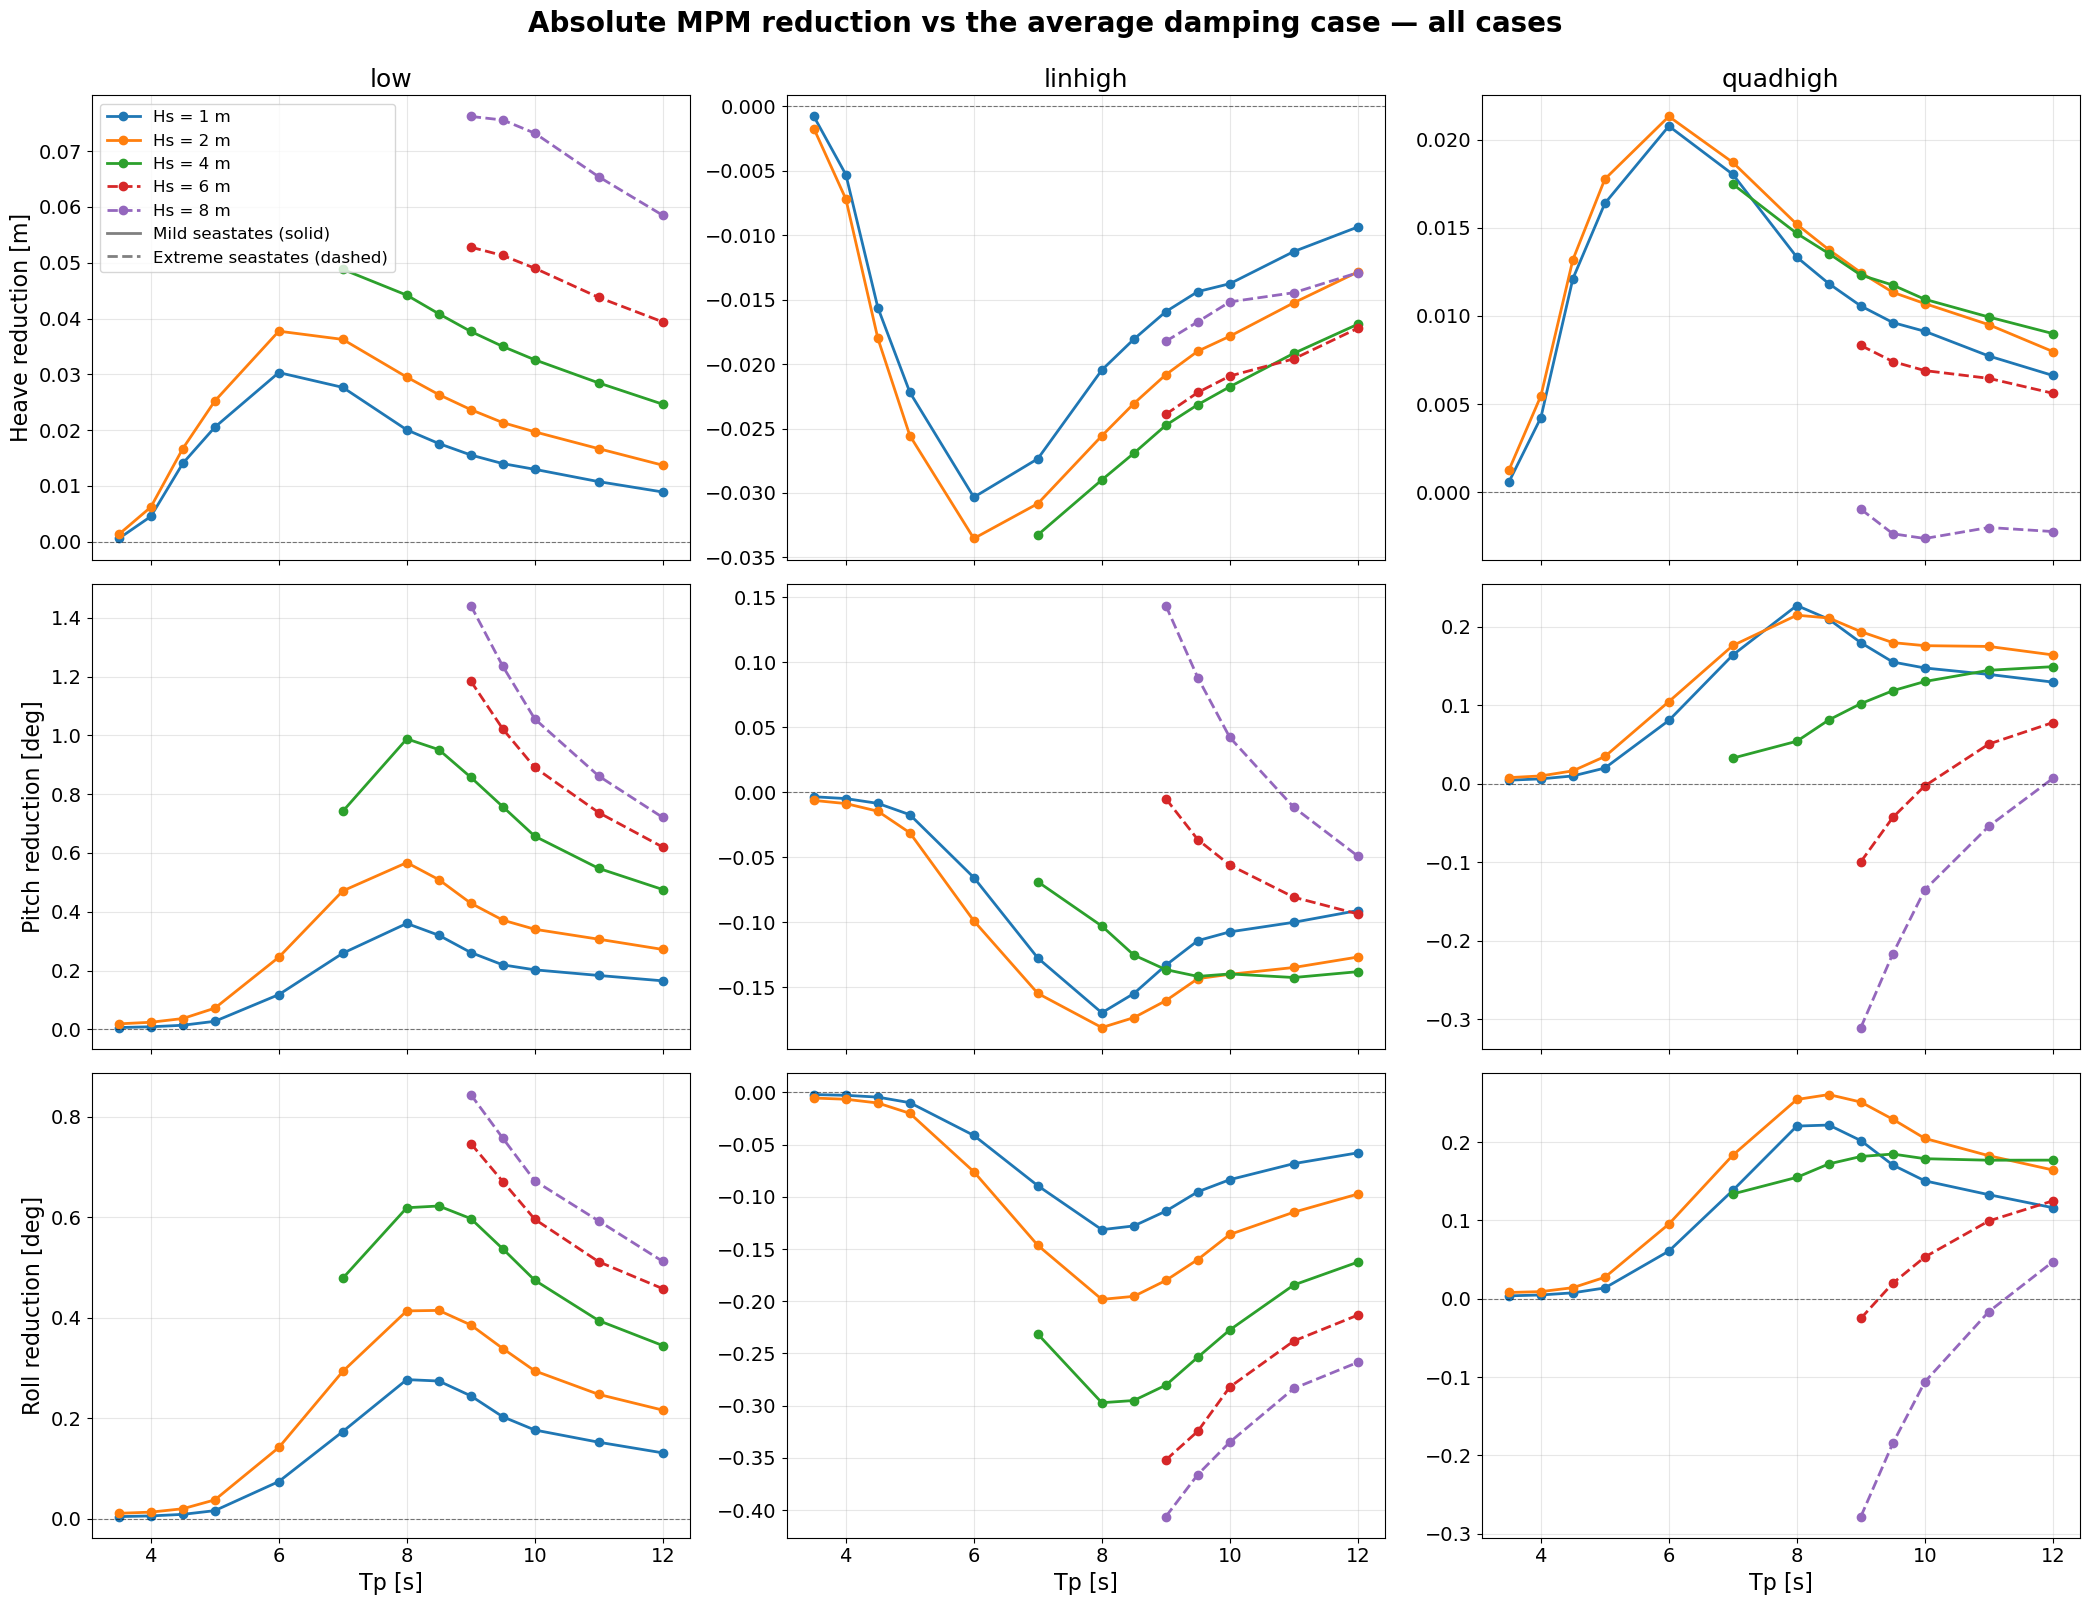

In [5]:
# CASES = ['linhigh', 'quadhigh', 'average']
UNITS = {'Z': 'm', 'pitch': 'deg', 'roll': 'deg'}
HS_COLORS = {hs: c for hs, c in zip(HS_ALL, plt.cm.viridis(np.linspace(0, 0.85, len(HS_ALL))))}

fig, axes = plt.subplots(3, 3, figsize=(21, 16), squeeze=False, sharex=True)

for r, dof in enumerate(DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'
    for cc, case in enumerate(CASES):
        ax = axes[r, cc]
        for hs in HS_ALL:
            sub_hs = sub_dof[sub_dof['Hs'] == hs]
            base = sub_hs[sub_hs[dcol] == 'average'].groupby('Tp')[mpm_c].mean().sort_index()
            cur  = sub_hs[sub_hs[dcol] == case].groupby('Tp')[mpm_c].mean().sort_index()
            common = base.index.intersection(cur.index)
            if len(common) == 0:
                continue
            diff = cur.loc[common] - base.loc[common]
            ax.plot(common, diff, hs_style(hs), marker='o', 
                    linewidth=2, markersize=6, label=f'Hs = {hs} m')
        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=TICK_SIZE)
        if r == 0:
            ax.set_title(case, fontsize=TITLE_SIZE)
        if cc == 0:
            ax.set_ylabel(f'{dof["name"]} reduction [{UNITS[dof["key"]]}]', fontsize=LABEL_SIZE)
        if r == 2:
            ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)

handles, labels = axes[0, 0].get_legend_handles_labels()
style_handles = [Line2D([0],[0],color='grey',ls='-',lw=2),
                 Line2D([0],[0],color='grey',ls='--',lw=2)]
axes[0, 0].legend(handles + style_handles, labels + ['Mild seastates (solid)', 'Extreme seastates (dashed)'],
                  fontsize=TICK_SIZE - 2, ncol=1, loc='best')

fig.suptitle('Absolute MPM reduction vs the average damping case \u2014 all cases',
             fontsize=TITLE_SIZE + 2, fontweight='bold', y=1.00)
fig.tight_layout()
fig.savefig('fig_allcases_absolute.png', dpi=200, bbox_inches='tight')
plt.show()